Title: capacity_data.ipynb

Purpose: Transform the xml capacity data into some gridded format

Author: Onno Nennecke on 10.02.2025 Modified: 10.02.2025

Input data: 

    - This file lies here: 

Output data:

    - This file lies here: 

In [1]:
import pandas as pd
import geopandas as gpd
import xml.etree.ElementTree as ET
import xarray as xr
import numpy as np


In [2]:
# Load the XML file
tree = ET.parse('/climca/people/onennecke/Wind_Solar_MaStR/EinheitenSolar_1.xml')
root = tree.getroot()


In [3]:
# Initialize a list to store the rows
rows = []

# Loop through each <EinheitSolar> element
for unit_elem in root.findall('EinheitSolar'):
    row_data = {}
    # Extract each child tag of <EinheitSolar> as a column
    for field in unit_elem:
        column_name = field.tag  # The tag name becomes the column name
        column_value = field.text  # The text inside the tag is the value
        row_data[column_name] = column_value
    rows.append(row_data)

# Convert the list of rows to a Pandas DataFrame
df = pd.DataFrame(rows)

# Display the DataFrame
print(df)

      EinheitMastrNummer    DatumLetzteAktualisierung LokationMaStRNummer  \
0        SEE984033548619  2020-02-20T16:28:35.2508122     SEL948991715391   
1        SEE901901460125  2021-07-15T07:54:37.8637095     SEL982068309366   
2        SEE983679054270  2019-05-28T08:26:38.0316692     SEL906699064968   
3        SEE978732598938  2020-12-07T08:19:07.9860793     SEL996128012264   
4        SEE970592691989  2021-01-25T11:18:30.0433603     SEL975715515692   
...                  ...                          ...                 ...   
99995    SEE930827157994  2019-05-28T08:26:38.0316692     SEL915079387696   
99996    SEE973401870377  2023-12-01T15:45:39.3089381     SEL932176968740   
99997    SEE993631096538  2019-05-28T08:26:38.0316692     SEL992799156399   
99998    SEE953193068237  2019-10-11T05:45:22.1168134     SEL912706478208   
99999    SEE914160719248  2024-06-07T05:37:29.4841354     SEL968365989661   

      NetzbetreiberpruefungStatus AnlagenbetreiberMastrNummer Land Bundesla

In [4]:
import sys
sys.getsizeof(df) / 1024 / 1024 # in MB

272.6333303451538

In [5]:
# Drop closed units
df_1 = df[df['EinheitBetriebsstatus'] == '35'] # 35 == In Betrieb

# Drop units which are not in Germany (There seem to be very rare international units in the dataset)
df_1 = df_1[df_1['Land'] == '84'] # 84 == Deutschland 

In [6]:
# Felder relevant:
columns_to_keep = ['EinheitMastrNummer', 'Postleitzahl', 'Bruttoleistung', 'Nettonennleistung',
  'AnzahlModule', 'Lage', 'Gemeinde', 'Laengengrad', 'Breitengrad']

# Liste Felder nicht relevant:
columns_to_loose = ['DatumLetzteAktualisierung', 'LokationMaStRNummer',
       'NetzbetreiberpruefungStatus', 'AnlagenbetreiberMastrNummer', 'Land', 
       'Bundesland', 'Landkreis', 'Ort',
       'Registrierungsdatum', 'Inbetriebnahmedatum', 'EinheitSystemstatus',
       'EinheitBetriebsstatus', 'NichtVorhandenInMigriertenEinheiten',
       'NameStromerzeugungseinheit', 'Weic_nv', 'Kraftwerksnummer_nv',
       'Energietraeger', 'FernsteuerbarkeitNb', 'Einspeisungsart',
       'ZugeordneteWirkleistungWechselrichter', 'Leistungsbegrenzung',
       'EinheitlicheAusrichtungUndNeigungswinkel', 'Hauptausrichtung',
       'HauptausrichtungNeigungswinkel', 'Nutzungsbereich', 'EegMaStRNummer',
       'Nebenausrichtung', 'NebenausrichtungNeigungswinkel',
       'DatumBeginnVoruebergehendeStilllegung', 'NetzbetreiberpruefungDatum',
       'Adresszusatz', 'FernsteuerbarkeitDv', 'DatumDesBetreiberwechsels',
       'DatumRegistrierungDesBetreiberwechsels', 'Gemarkung', 'FlurFlurstuecknummern',
       'AnschlussAnHoechstOderHochSpannung', 'InAnspruchGenommeneFlaeche',
       'ArtDerFlaecheIds', 'DatumEndgueltigeStilllegung', 'InAnspruchGenommeneAckerflaeche',
       'GenMastrNummer', 'Einsatzverantwortlicher', 'WeicDisplayName',
       'DatumWiederaufnahmeBetrieb', 'GeplantesInbetriebnahmedatum',
       'Buergerenergie', 'Kraftwerksnummer', 'Strasse', 'StrasseNichtGefunden', 'Hausnummer_nv',
       'Hausnummer', 'HausnummerNichtGefunden','Gemeindeschluessel']

In [7]:
filtered_df_1 = df_1[columns_to_keep]

In [8]:
# Count the number of NaN values in the 'column_name' column
nan_count = filtered_df_1['Postleitzahl'].isna().sum()

# Print the count of NaN values
print(f"Count of NaN values in 'Postleitzahl': {nan_count}")

Count of NaN values in 'Postleitzahl': 0


In [9]:
filtered_df_1

,EinheitMastrNummer,Postleitzahl,Bruttoleistung,Nettonennleistung,AnzahlModule,Lage,Gemeinde,Laengengrad,Breitengrad
0,SEE984033548619,48147,3.960,3.960,22,853,Münster,NaN,NaN
1,SEE901901460125,73529,7.410,7.410,38,853,Schwäbisch Gmünd,NaN,NaN
2,SEE983679054270,14641,5.040,5.000,16,853,Nauen,NaN,NaN
3,SEE978732598938,93080,6.360,6.000,24,853,Pentling,NaN,NaN
4,SEE970592691989,66740,7.200,7.200,30,853,Saarlouis,NaN,NaN
...,...,...,...,...,...,...,...,...,...
99995,SEE930827157994,96215,17.400,17.400,60,853,Lichtenfels,NaN,NaN
99996,SEE973401870377,95119,99.430,90.000,326,853,Naila,11.706000,50.328000
99997,SEE993631096538,25715,33.060,32.000,NaN,853,Eddelak,9.155000,53.952000
99998,SEE953193068237,01768,72.105,66.000,253,853,Glashütte,13.706571,50.863468


In [10]:
# Create centroids
# Lade eine Shapefile mit PLZ-Geometrien (z.B. aus OpenStreetMap oder von Statistikbehörden)
plz_shp = gpd.read_file("/climca/people/onennecke/PLZ_Germany/OSM_PLZ.shp")

# Daten mit PLZ-Zentroiden verknüpfen
plz_shp["geometry"] = plz_shp.geometry.centroid

# Reproject data
gdf_latlong = plz_shp.to_crs(epsg=4326)

# print(gdf_latlong.crs)


gdf_latlong['x'] = gdf_latlong['geometry'].x
gdf_latlong['y'] = gdf_latlong['geometry'].y
gdf_latlong

plz_df = gdf_latlong[["plz", "geometry", "x", "y"]]
plz_df

,plz,geometry,x,y
0,64743,POINT (8.98561 49.6067),8.985609,49.606698
1,81248,POINT (11.40315 48.14827),11.403147,48.148274
2,60315,POINT (8.67392 50.1123),8.673919,50.112304
3,99331,POINT (10.82683 50.71362),10.826825,50.713624
4,60312,POINT (8.67302 50.11155),8.673024,50.111553
...,...,...,...,...
8165,63874,POINT (9.34342 49.86497),9.343419,49.864974
8166,63856,POINT (9.26131 49.96501),9.261309,49.965013
8167,63869,POINT (9.35162 50.03609),9.351621,50.036092
8168,75339,POINT (8.57751 48.80104),8.577507,48.801035


In [11]:
list_plz_nd = set(filtered_df_1["Postleitzahl"]) - set(plz_df["plz"])       # These PLZs are not in the PLZ shapefile
print(len(set(filtered_df_1["Postleitzahl"])))                              # 7560 unique PLZs in the dataset
print(len(set(plz_df["plz"])))                                              # 8170 PLZs in Deutschland
print(len(list_plz_nd))                                                     # 12 PLZs are not in the PLZ shapefile --> Outdated
print(len(filtered_df_1[filtered_df_1['Postleitzahl'].isin(list_plz_nd)]))  # These 12 PLZs are 20 times in the dataset
print(len(set(plz_df["plz"]) - set(filtered_df_1["Postleitzahl"]) ))        # 622 PLZs are in the PLZ shapefile but not in the dataset??
print(list_plz_nd)                                                          # These PLZs are not in the PLZ shapefile

7560
8170
12
20
622
{'31196', '31035', '98708', '98554', '98678', '37449', '98739', '06578', '31097', '98704', '31093', '21784'}


In [12]:
# Merge the two DataFrames
merged_df = pd.merge(filtered_df_1, plz_df, left_on='Postleitzahl', right_on='plz')

merged_df = gpd.GeoDataFrame(merged_df, geometry=gpd.points_from_xy(merged_df.y, merged_df.x))
# merged_df

In [ ]:
merged_df['EinheitMastrNummer'] = merged_df['EinheitMastrNummer'].astype(str)
merged_df['Bruttoleistung'] = merged_df['Bruttoleistung'].astype(float)
merged_df['Nettonennleistung'] = merged_df['Nettonennleistung'].astype(float)
merged_df['AnzahlModule'] = merged_df['AnzahlModule'].astype('Int64')
merged_df['Lage'] = merged_df['Lage'].astype(str)
merged_df['Gemeinde'] = merged_df['Gemeinde'].astype(str)
merged_df['Laengengrad'] = merged_df['Laengengrad'].astype(float)
merged_df['Breitengrad'] = merged_df['Breitengrad'].astype(float)
merged_df.drop(columns=['plz'], inplace=True)
merged_df

,EinheitMastrNummer,Postleitzahl,Bruttoleistung,Nettonennleistung,AnzahlModule,Lage,Gemeinde,Laengengrad,Breitengrad,geometry,x,y
0,SEE984033548619,48147,3.960,3.96,22,853,Münster,NaN,NaN,POINT (51.97761 7.63545),7.635453,51.977610
1,SEE901901460125,73529,7.410,7.41,38,853,Schwäbisch Gmünd,NaN,NaN,POINT (48.76784 9.83615),9.836154,48.767840
2,SEE983679054270,14641,5.040,5.00,16,853,Nauen,NaN,NaN,POINT (52.61294 12.82297),12.822970,52.612939
3,SEE978732598938,93080,6.360,6.00,24,853,Pentling,NaN,NaN,POINT (48.96016 12.06057),12.060572,48.960157
4,SEE970592691989,66740,7.200,7.20,30,853,Saarlouis,NaN,NaN,POINT (49.31122 6.74754),6.747539,49.311221
...,...,...,...,...,...,...,...,...,...,...,...,...
99106,SEE930827157994,96215,17.400,17.40,60,853,Lichtenfels,NaN,NaN,POINT (50.13827 11.08432),11.084317,50.138266
99107,SEE973401870377,95119,99.430,90.00,326,853,Naila,11.706000,50.328000,POINT (50.32292 11.68663),11.686627,50.322918
99108,SEE993631096538,25715,33.060,32.00,<NA>,853,Eddelak,9.155000,53.952000,POINT (53.94891 9.14598),9.145978,53.948912
99109,SEE953193068237,1768,72.105,66.00,253,853,Glashütte,13.706571,50.863468,POINT (50.86274 13.75784),13.757841,50.862743


In [14]:
# Load climate data as a grid reference
nc = xr.open_dataset('/climca/data/CMIP6/CMIP/NCAR/CESM2/historical/r1i1p1f1/day/sfcWind/gn/v20190308/sfcWind_day_CESM2_historical_r1i1p1f1_gn_18500101-18591231.nc')
nc = nc.sel(dict(lat=slice(45,60), lon=slice(5,15))) # At the moment roughly germany
# Koordinaten des Rasters extrahieren
lats = nc['lat'].values  # Latitude
lons = nc['lon'].values  # Longitude

# Optional: Werte für das leere Grid initialisieren (z. B. mit NaN oder 0)
empty_grid = np.full((len(lats), len(lons)), np.nan)

# Neues xarray.DataArray basierend auf den Dimensionen erstellen
grid = xr.DataArray(
    data=empty_grid,
    coords={"lat": lats, "lon": lons},
    dims=["lat", "lon"],
    name="empty_grid"
)
grid

/home/onennecke/.conda/envs/on_ma_env/lib/python3.13/site-packages/xarray/conventions.py:189: SerializationWarning: variable 'sfcWind' has multiple fill values {np.float32(1e+20), np.float64(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)


<xarray.DataArray 'empty_grid' (lat: 16, lon: 9)> Size: 1kB
array([[nan, nan, nan, nan, nan, nan, nan, nan, nan],
       [nan, nan, nan, nan, nan, nan, nan, nan, nan],
       [nan, nan, nan, nan, nan, nan, nan, nan, nan],
       [nan, nan, nan, nan, nan, nan, nan, nan, nan],
       [nan, nan, nan, nan, nan, nan, nan, nan, nan],
       [nan, nan, nan, nan, nan, nan, nan, nan, nan],
       [nan, nan, nan, nan, nan, nan, nan, nan, nan],
       [nan, nan, nan, nan, nan, nan, nan, nan, nan],
       [nan, nan, nan, nan, nan, nan, nan, nan, nan],
       [nan, nan, nan, nan, nan, nan, nan, nan, nan],
       [nan, nan, nan, nan, nan, nan, nan, nan, nan],
       [nan, nan, nan, nan, nan, nan, nan, nan, nan],
       [nan, nan, nan, nan, nan, nan, nan, nan, nan],
       [nan, nan, nan, nan, nan, nan, nan, nan, nan],
       [nan, nan, nan, nan, nan, nan, nan, nan, nan],
       [nan, nan, nan, nan, nan, nan, nan, nan, nan]])
Coordinates:
  * lat      (lat) float64 128B 45.71 46.65 47.59 48.53 ... 57.96 58.9 59.84
  * lon      (lon) float64 72B 5.0 6.25 7.5 8.75 10.0 11.25 12.5 13.75 15.0

In [15]:
merged_df['Bruttoleistung'].sum()

np.float64(3822824.903)

In [20]:
merged_df

,EinheitMastrNummer,Postleitzahl,Bruttoleistung,Nettonennleistung,AnzahlModule,Lage,Gemeinde,Laengengrad,Breitengrad,geometry,x,y,lat_idx,lon_idx
0,SEE984033548619,48147,3.960,3.96,22,853,Münster,NaN,NaN,POINT (51.97761 7.63545),7.635453,51.977610,6,2
1,SEE901901460125,73529,7.410,7.41,38,853,Schwäbisch Gmünd,NaN,NaN,POINT (48.76784 9.83615),9.836154,48.767840,3,3
2,SEE983679054270,14641,5.040,5.00,16,853,Nauen,NaN,NaN,POINT (52.61294 12.82297),12.822970,52.612939,7,6
3,SEE978732598938,93080,6.360,6.00,24,853,Pentling,NaN,NaN,POINT (48.96016 12.06057),12.060572,48.960157,3,5
4,SEE970592691989,66740,7.200,7.20,30,853,Saarlouis,NaN,NaN,POINT (49.31122 6.74754),6.747539,49.311221,3,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99106,SEE930827157994,96215,17.400,17.40,60,853,Lichtenfels,NaN,NaN,POINT (50.13827 11.08432),11.084317,50.138266,4,4
99107,SEE973401870377,95119,99.430,90.00,326,853,Naila,11.706000,50.328000,POINT (50.32292 11.68663),11.686627,50.322918,4,5
99108,SEE993631096538,25715,33.060,32.00,<NA>,853,Eddelak,9.155000,53.952000,POINT (53.94891 9.14598),9.145978,53.948912,8,3
99109,SEE953193068237,1768,72.105,66.00,253,853,Glashütte,13.706571,50.863468,POINT (50.86274 13.75784),13.757841,50.862743,5,7


In [16]:
# Schritt 2: Koordinaten zu Grid-Zellen zuordnen
# Wandle Koordinaten in das Grid-Koordinatensystem (Anpassung kann nötig sein!)
merged_df["lat_idx"] = np.searchsorted(grid['lat'], merged_df["y"]) - 1  # Zeilenindex für Latitude
merged_df["lon_idx"] = np.searchsorted(grid['lon'], merged_df["x"]) - 1  # Spaltenindex für Longitude



In [17]:
grid_sums = merged_df.groupby(["lat_idx", "lon_idx"])["Bruttoleistung"].sum()
# grid_sums

In [18]:
# Schritt 4: Werte ins Grid schreiben
for (lat_idx, lon_idx), value in grid_sums.items():
    grid[lat_idx, lon_idx] = value

# Resultierendes Grid anzeigen
print(grid)

<xarray.DataArray 'empty_grid' (lat: 16, lon: 9)> Size: 1kB
array([[           nan,            nan,            nan,            nan,
                   nan,            nan,            nan,            nan,
                   nan],
       [           nan,            nan, 7.51395000e+02, 4.14300000e+02,
        3.02161600e+03, 2.43600000e+01, 1.48830000e+02,            nan,
                   nan],
       [           nan,            nan, 5.17289850e+04, 1.16917462e+05,
        9.61965010e+04, 1.01972823e+05, 6.66113760e+04,            nan,
                   nan],
       [           nan, 3.77165900e+04, 7.00940040e+04, 9.95110020e+04,
        1.44834330e+05, 1.75757905e+05, 1.00290804e+05, 6.05410000e+02,
                   nan],
       [7.51620000e+02, 8.18315720e+04, 7.53899870e+04, 7.03430320e+04,
        1.14220897e+05, 8.19624550e+04, 1.52385600e+03,            nan,
                   nan],
       [1.35250560e+04, 7.92186560e+04, 4.07401350e+04, 7.68596550e+04,
        9.46552580e+04,

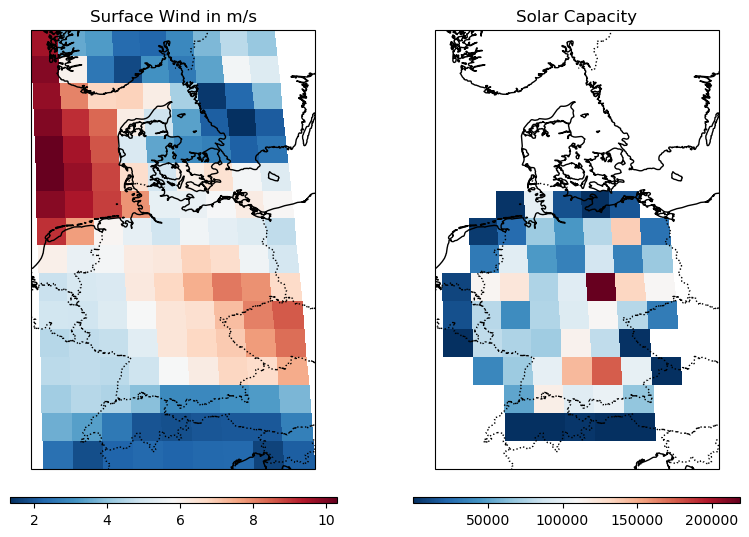

In [19]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature


# grid.plot()

sfcWind = nc['sfcWind'] 


# Plot the data
timestep = 1

fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(9, 6), subplot_kw={'projection': ccrs.Robinson()})

# First subplot
ax1.coastlines()
ax1.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='black')
xxx = sfcWind.isel(time=timestep)
im1 = ax1.pcolormesh(xxx.lon, xxx.lat, xxx, transform=ccrs.PlateCarree(), cmap='RdBu_r')
cbar1 = fig.colorbar(im1, ax=ax1, orientation='horizontal', pad=0.05, shrink=0.7, aspect=50)
ax1.set_title('Surface Wind in m/s')


# Second subplot
ax2.coastlines()
ax2.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='black')

xxx = grid
im2 = ax2.pcolormesh(xxx.lon, xxx.lat, xxx, transform=ccrs.PlateCarree(), cmap='RdBu_r')
cbar2 = fig.colorbar(im2, ax=ax2, orientation='horizontal', pad=0.05, shrink=0.7, aspect=50)
ax2.set_title('Solar Capacity')


plt.tight_layout()
plt.show()